### Libraries.

In [1]:
from anndata import AnnData
from matplotlib import rcParams
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scanpy as sc
from sklearn.preprocessing import OneHotEncoder
import torch
from tqdm import tqdm

from sc_exp_design.models import FlowMatching

# defining figure size
FIGSIZE = (3, 3)
rcParams["figure.figsize"] = FIGSIZE


### Load Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

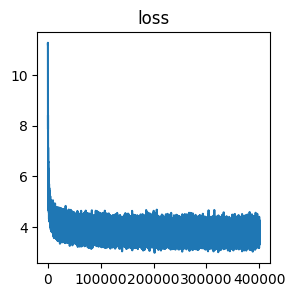

In [29]:
PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-07-16_21-17-28/charmed-morning-21_FlowMatching.pkl"
flow_matching = FlowMatching.load(PATH)
flow_matching.trainer.plot_training_logs()


### Generating some events.

In [30]:
n_samples_per_protocol = 5_000
protocols_one_hot = flow_matching.train_data.adata.uns["protocol_one_hot"]
samples_per_protocol = {}
for protocol_string, protocol_oh in tqdm(protocols_one_hot.items()):
    samples_per_protocol[protocol_string] = flow_matching.predict(
        batch={
            "condition": {
                "repr_protocol_protocol_one_hot": torch.from_numpy(protocol_oh).unsqueeze(0).repeat(n_samples_per_protocol, 1).to(flow_matching.device),
            }
        },
        batch_size=n_samples_per_protocol,
    ).detach().cpu().numpy()


  0%|          | 0/73 [00:00<?, ?it/s]

100%|██████████| 73/73 [00:02<00:00, 35.17it/s]


### Concatenating the results and retrieving the observation columns.

In [31]:
adata = flow_matching.train_data.adata
subsample_done = False

if not subsample_done:
    subsample_done = True
    sc.pp.subsample(adata, 0.01)

X_generated = np.concatenate(list(samples_per_protocol.values()), axis=0)
obs_colums = {
    "protocol": adata.obs["protocol"].tolist() + [protocol_str for _ in range(n_samples_per_protocol) for protocol_str in samples_per_protocol.keys()],
}
X_generated.shape


(365000, 21)

### KDE plot of generated samples per channel.

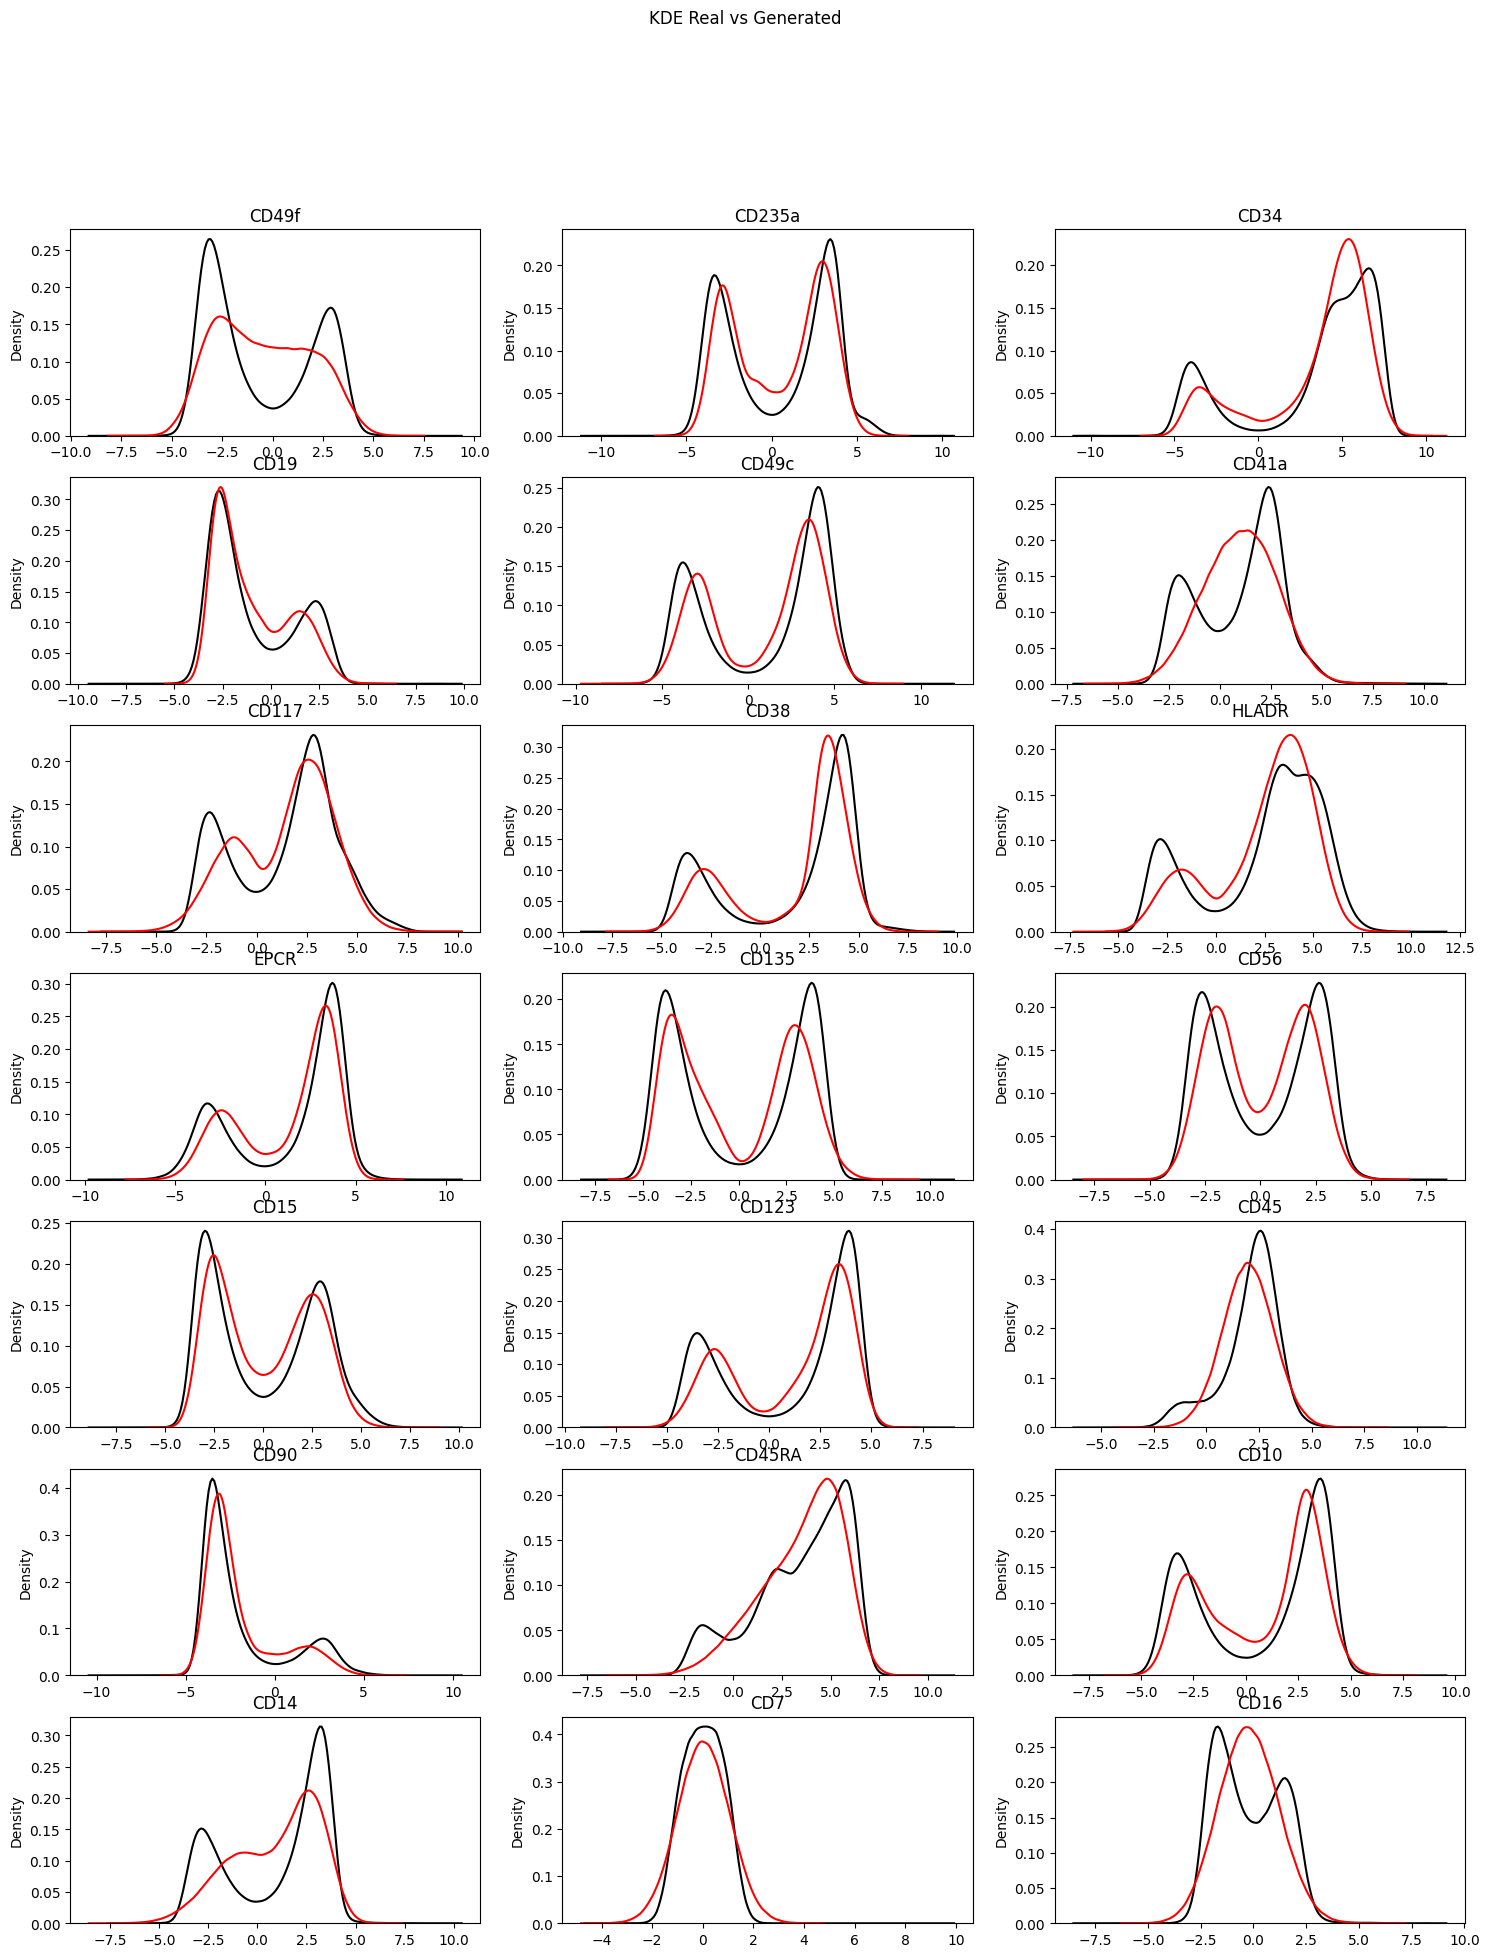

In [32]:
data = adata.obsm["X_repr"]

int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}
dims = data.shape[1]  # 21

fig, axs = plt.subplots(7, 3, figsize=(18, 22))
fig.suptitle("KDE Real vs Generated")
axs = axs.flatten()

for dim in range(dims):
    ax = axs[dim]
    ax.set_title(adata.var_names[dim])
    # KDE from data
    sns.kdeplot(data[:, dim], ax=ax, label='KDE Data', color='black')
    sns.kdeplot(X_generated[:, dim], ax=ax, label='KDE Samples', color='red')



### Defining function to visualize generated samples.

In [5]:
def concatenate_adata_and_plot(
    adata, samples, plot_pcs=True, plot_umap=True, subsample_size=0.1, coloring=["dataset_type"], key="X_repr", **kwargs
):
    obs = {"dataset_type": ["Real" for _ in range(adata.shape[0])] + ["Generated" for _ in range(samples.shape[0])], **kwargs}
    adata_generated = AnnData(X=np.concatenate([adata.obsm[key], samples], axis=0), obs=obs)
    adata_generated.obsm[key] = adata_generated.X.copy()

    if plot_umap:
        sc.pp.subsample(adata_generated, subsample_size)
        sc.pp.neighbors(adata_generated)
        sc.tl.umap(adata_generated)
        
    for color in coloring:
        if plot_pcs:
            sc.pl.embedding(adata_generated, basis=key, color=color)
        if plot_umap:
            sc.pl.umap(adata_generated, color=color)
    return adata_generated


### Visualizing the generated samples.


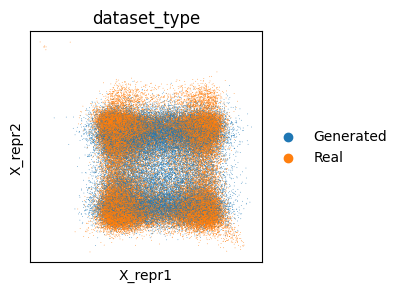

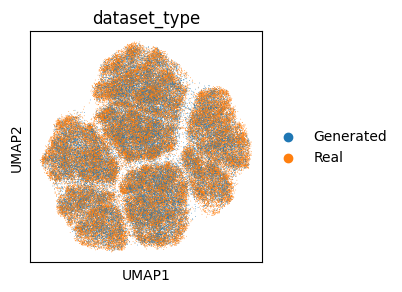

In [33]:
adata_generated = concatenate_adata_and_plot(
    adata,
    X_generated,
    key=flow_matching.data_manager.sample_rep,
    **obs_colums
)
